## import modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
import shutil
import os
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf 

## load the dataset

In [2]:
IMAGE_FOLDER = 'tusimple_processed/images'
MASK_FOLDER = 'tusimple_processed/masks'

In [3]:
def create_dir(dir_path):
    if not os.path.exists(dir_path):
        os.makedirs(dir_path)
        print("directory created:", dir_path)
    else:
        print("directory already exists:", dir_path)

In [4]:
create_dir(IMAGE_FOLDER)
create_dir(MASK_FOLDER)

directory created: tusimple_processed/images
directory created: tusimple_processed/masks


### move images to the image directory

In [5]:
CLIPS_PATH = "/kaggle/input/datasets/manideep1108/tusimple/TUSimple/train_set/clips"

# iterate through each directory  
for clip_dir in os.listdir(CLIPS_PATH):
    clip_dir_path = os.path.join(CLIPS_PATH, clip_dir)

    print("processing clip:", clip_dir)
    
    #iterate through each sub-directory
    for frame_dir in os.listdir(clip_dir_path):
        frame_path = os.path.join(clip_dir_path, frame_dir, "20.jpg")

        # check if file is present
        if not os.path.isfile(frame_path):
            continue

        # create new filename based on last 2 directory names
        temp = frame_path[:-7].split('/')[-2:]
        new_filename = f"{temp[0]}_{temp[1]}.jpg"
        new_file_path = os.path.join(IMAGE_FOLDER, new_filename)

        # copy the file 
        shutil.copy(frame_path, new_file_path) 

processing clip: 0531
processing clip: 0601
processing clip: 0313-2
processing clip: 0313-1


In [6]:
print("total number of images in dataset:", len(os.listdir(IMAGE_FOLDER))) 

total number of images in dataset: 3626


### create masks for the images

In [8]:
# load the json label files 
df1 = pd.read_json("/kaggle/input/datasets/manideep1108/tusimple/TUSimple/train_set/label_data_0313.json", lines = True)
df2 = pd.read_json("/kaggle/input/datasets/manideep1108/tusimple/TUSimple/train_set/label_data_0531.json", lines = True)
df3 = pd.read_json("/kaggle/input/datasets/manideep1108/tusimple/TUSimple/train_set/label_data_0601.json", lines = True)

# combine into a single dataframe
df = pd.concat([df1, df2, df3])
df.head() 

,lanes,h_samples,raw_file
0,"[[-2, -2, -2, -2, 632, 625, 617, 609, 601, 594...","[240, 250, 260, 270, 280, 290, 300, 310, 320, ...",clips/0313-1/6040/20.jpg
1,"[[-2, -2, -2, 658, 646, 635, 623, 612, 601, 58...","[240, 250, 260, 270, 280, 290, 300, 310, 320, ...",clips/0313-1/5320/20.jpg
2,"[[-2, 570, 554, 538, 522, 505, 489, 473, 456, ...","[240, 250, 260, 270, 280, 290, 300, 310, 320, ...",clips/0313-1/23700/20.jpg
3,"[[-2, -2, -2, -2, 555, 542, 530, 517, 505, 493...","[240, 250, 260, 270, 280, 290, 300, 310, 320, ...",clips/0313-1/51660/20.jpg
4,"[[-2, -2, -2, 522, 525, 528, 531, 534, 537, 53...","[240, 250, 260, 270, 280, 290, 300, 310, 320, ...",clips/0313-1/25680/20.jpg


In [9]:
# create a function for generating masks 
def generate_lane_mask(row):
    # create a mask of all zeros
    mask = np.zeros((720, 1280, 1), dtype = np.uint8) 

    # extract data from rows
    h_samples = row.h_samples
    lanes = row.lanes
    raw_file = row.raw_file

    # create mask: lane = 1, non-lane = 0
    for lane in lanes:
        # exclude 2 datapoints
        h_samples_filtered = [y for x, y in zip(lane, h_samples) if x != -2]
        lane_filtered = [x for x in lane if x != -2]

        # create array of lane points
        lane_points = np.array(list(zip(lane_filtered, h_samples_filtered)))

        # update lane mask
        cv2.polylines(mask, [lane_points], isClosed = False, color = (255, 255, 255), thickness = 15)

    # generate mask filenames
    temp = raw_file[:-7].split('/')[-2:]
    mask_filename = f"{temp[0]}_{temp[1]}.jpg"
    mask_filename_path = os.path.join(MASK_FOLDER, mask_filename)

    # write the mask image
    cv2.imwrite(mask_filename_path, mask) 

In [10]:
for index, row in tqdm(df.iterrows(), total = len(df)):
    generate_lane_mask(row) 

  0%|          | 0/3626 [00:00<?, ?it/s]

In [11]:
print("total masks in dataset:", len(os.listdir(MASK_FOLDER))) 

total masks in dataset: 3626


## data visualization

In [12]:
def visualize_image(image_name):
    # get paths
    image_path = os.path.join(IMAGE_FOLDER, image_name)
    mask_path = os.path.join(MASK_FOLDER, image_name)

    # read the image and mask
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
    mask = cv2.imread(mask_path)

    # plot the figures
    plt.figure(figsize=(20, 8))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Road Image")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="gray")  
    plt.title("Ground Truth Mask")

    # show the images
    plt.show()

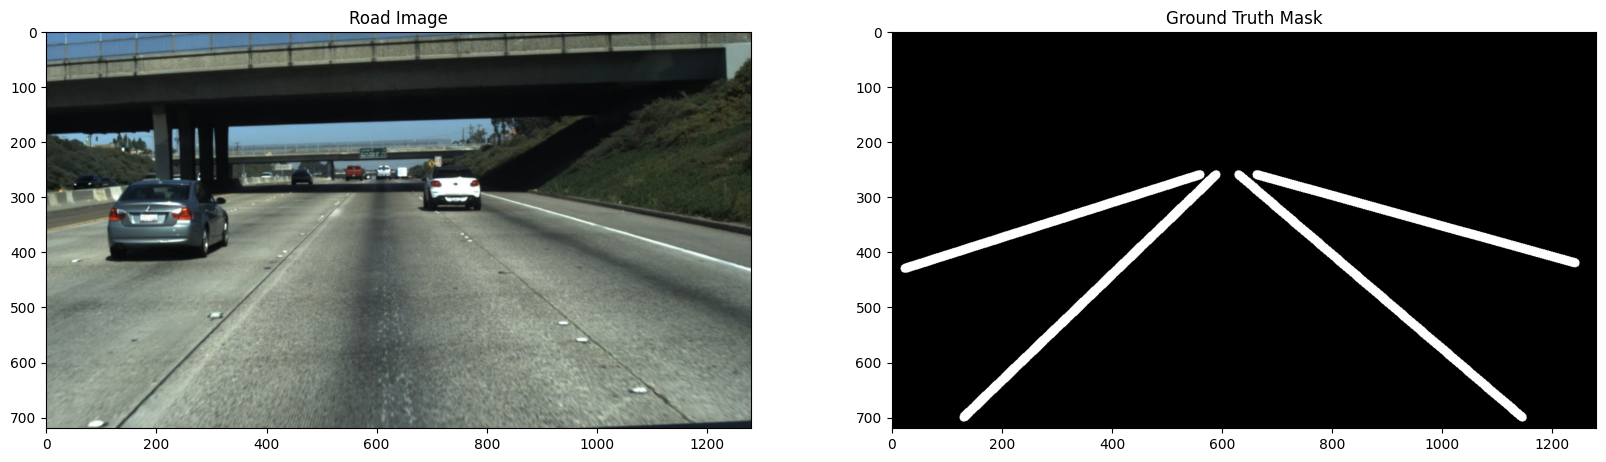

In [13]:
image_name = random.choice(os.listdir(IMAGE_FOLDER))
visualize_image(image_name)

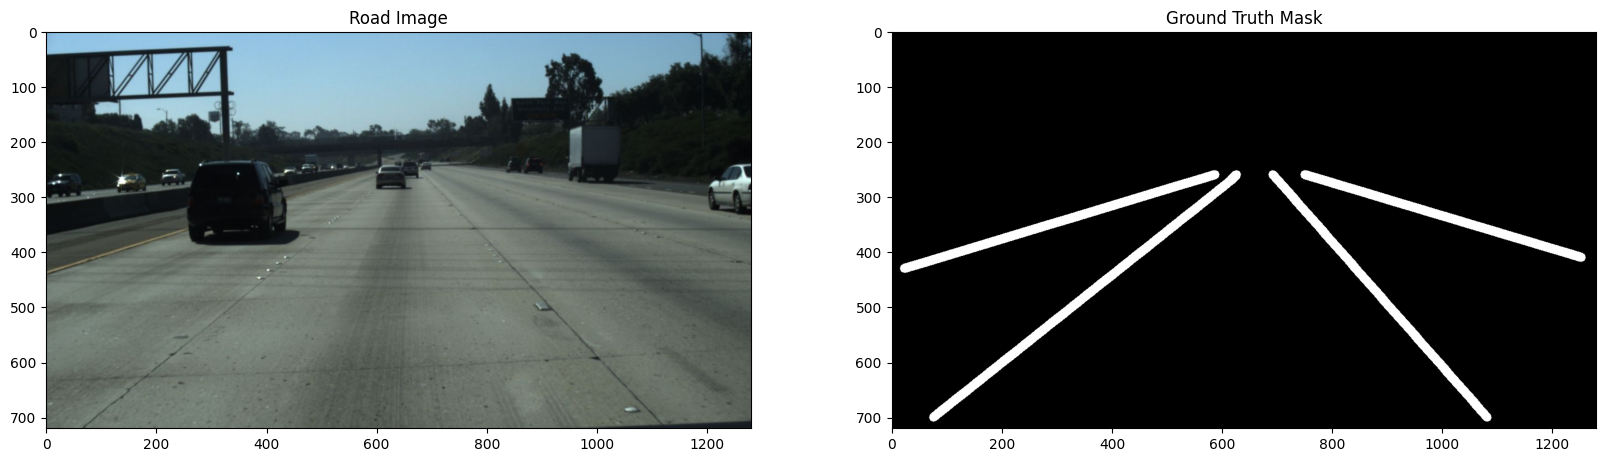

In [14]:
image_name = random.choice(os.listdir(IMAGE_FOLDER))
visualize_image(image_name)

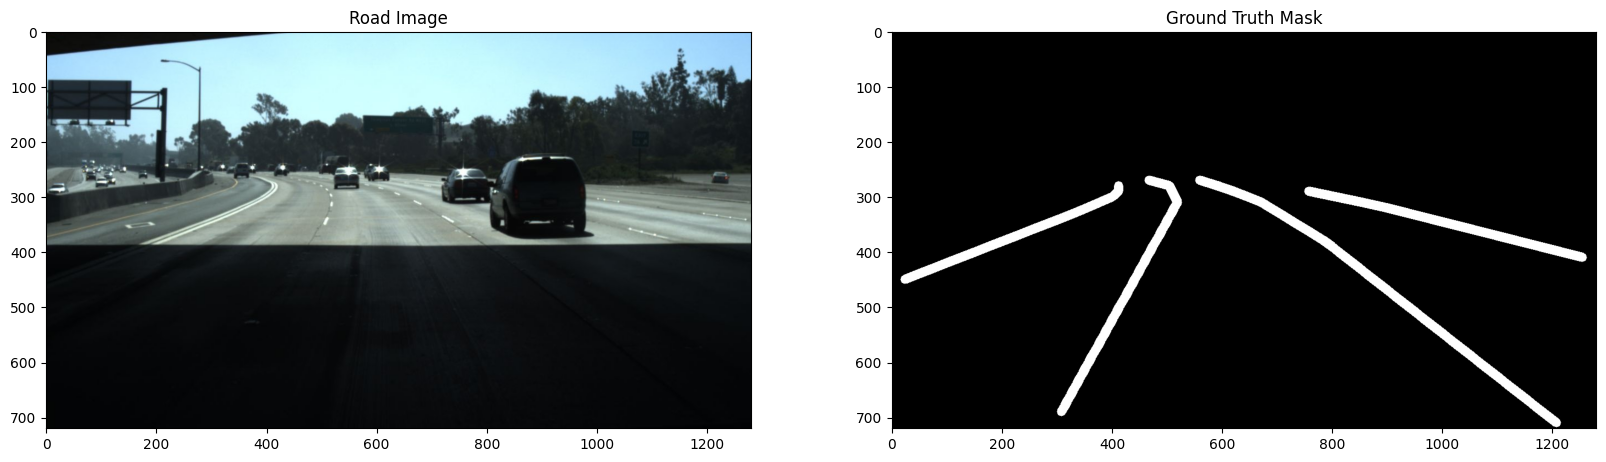

In [15]:
image_name = random.choice(os.listdir(IMAGE_FOLDER))
visualize_image(image_name)

## preprocess data for training and testing

In [16]:
train_image_folder = "tusimple_processed/train/images"
test_image_folder = "tusimple_processed/test/images"
train_mask_folder = "tusimple_processed/train/masks"
test_mask_folder = "tusimple_processed/test/masks" 

In [17]:
for folder_path in [train_image_folder, test_image_folder, train_mask_folder, test_mask_folder]:
    create_dir(folder_path) 

directory created: tusimple_processed/train/images
directory created: tusimple_processed/test/images
directory created: tusimple_processed/train/masks
directory created: tusimple_processed/test/masks


In [18]:
from sklearn.model_selection import train_test_split
images = [file for file in os.listdir(IMAGE_FOLDER) if file.endswith(".jpg")]
masks = [file for file in os.listdir(MASK_FOLDER) if file.endswith(".jpg")]

# split train, test images
train_images, test_images = train_test_split(images, test_size = 0.1, random_state = 42) 

In [19]:
len(train_images)

3263

In [20]:
len(test_images)

363

In [21]:
# move files to corresponding folders

for file in train_images:
    # move the image and mask
    source = os.path.join(IMAGE_FOLDER, file)
    destination = os.path.join(train_image_folder, file)
    shutil.move(source, destination)

    source = os.path.join(MASK_FOLDER, file)
    destination = os.path.join(train_mask_folder, file)
    shutil.move(source, destination) 

for file in test_images:
    # move the image and mask
    source = os.path.join(IMAGE_FOLDER, file)
    destination = os.path.join(test_image_folder, file)
    shutil.move(source, destination)

    source = os.path.join(MASK_FOLDER, file)
    destination = os.path.join(test_mask_folder, file)
    shutil.move(source, destination)

## Feature Engineering

In [47]:
def load_image(image_path, mask_path):
    size = [224, 224]
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels = 3)
    image = tf.image.resize(image, size)
    image = image/255.0       # normalize it to [0, 1]

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_jpeg(mask, channels = 1)
    mask = tf.image.resize(mask, size)
    mask = mask/255.0         # normalize it to [0, 1]

    return image, mask

def dataset_from_folder(image_folder, mask_folder):
    image_files = sorted([os.path.join(image_folder, file)
                          for file in os.listdir(image_folder) if file.endswith(".jpg")])
    mask_files = sorted([os.path.join(mask_folder, file)
                         for file in os.listdir(mask_folder) if file.endswith(".jpg")])

    dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
    dataset = dataset.map(lambda image_path, mask_path : load_image(image_path, mask_path))

    return dataset 

In [48]:
# load dataset from folder 

train_dataset = dataset_from_folder(train_image_folder, train_mask_folder)
test_dataset = dataset_from_folder(test_image_folder, test_mask_folder)

In [49]:
# set config
BATCH_SIZE = 32
BUFFER_SIZE = 1000

train_dataset = (train_dataset.cache().shuffle(BUFFER_SIZE).repeat().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
test_dataset = (test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)) 

In [50]:
def display_sample(image_list):
    plt.figure(figsize = (10, 10))

    titles = ['image', 'true mask', 'predicted mask']

    for i in range(len(image_list)):
        plt.subplot(1, len(image_list), i+1)
        plt.title(titles[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(image_list[i]))
        plt.axis("off")

    plt.show() 

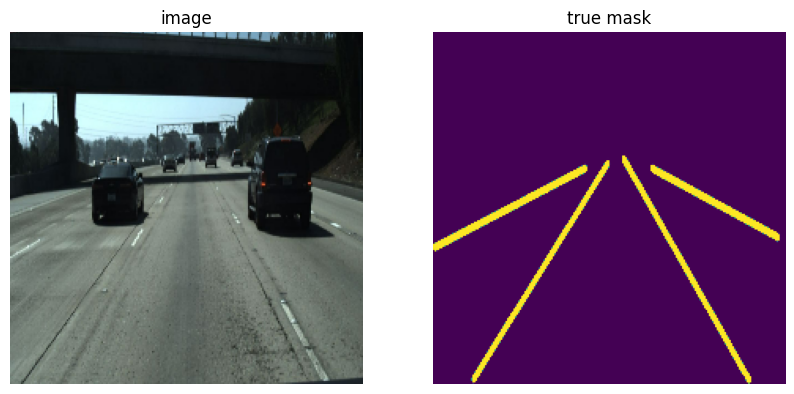

In [51]:
for image, mask in train_dataset.take(1):
    display_sample([image[0], mask[0]]) 

In [52]:
for batch in train_dataset.take(1):
    print("Train batch:", [x.shape for x in batch])

for batch in test_dataset.take(1):
    print("Test batch:", [x.shape for x in batch])

Train batch: [TensorShape([32, 224, 224, 3]), TensorShape([32, 224, 224, 1])]
Test batch: [TensorShape([32, 224, 224, 3]), TensorShape([32, 224, 224, 1])]


## Model Creation - VGG-UNet

In [53]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Dropout, Activation, Add, BatchNormalization, Conv2D, Concatenate, UpSampling2D
from tensorflow.keras.models import Model

def VGG16_UNet(input_shape = (None, None, 3)):
    
    """UNet architecture with VGG16 encoder (down/up sampling with skip architecture)"""
    
    def conv2dReluBatchNorm(n_filters, kernel_size, strides, inputs):
        x = Conv2D(n_filters, (1, 1), strides = 1, padding = "same", kernel_initializer = 'glorot_normal', activation = "elu")(inputs)
        x = Conv2D(n_filters, kernel_size, strides = strides, padding = "same", kernel_initializer = 'glorot_normal', activation = "elu")(x)
        x = BatchNormalization()(x)
        x = Dropout(rate = 0.25)(x, training = True)  # training +test-time dropout
        return x 

    # VGG16 encoder
    vgg16 = VGG16(weights = 'imagenet', include_top = False, input_shape = input_shape)

    # unfreeze vgg layers
    for layer in vgg16.layers:
        layer.trainable = True

    # encoder layers
    inputs = vgg16.input
    layer1 = vgg16.get_layer('block1_conv2').output
    layer2 = vgg16.get_layer('block2_conv2').output
    layer3 = vgg16.get_layer('block3_conv3').output
    layer4 = vgg16.get_layer('block4_conv3').output
    layer5 = vgg16.get_layer('block5_conv3').output

    # decoder layers
    merge6 = Concatenate(axis = -1)([UpSampling2D(size = (2, 2))(layer5), layer4])
    layer6 = conv2dReluBatchNorm(512, (3, 3), (1, 1), merge6)

    merge7 = Concatenate(axis = -1)([UpSampling2D(size = (2, 2))(layer6), layer3])
    layer7 = conv2dReluBatchNorm(256, (3, 3), (1, 1), merge7)

    merge8 = Concatenate(axis = -1)([UpSampling2D(size = (2, 2))(layer7), layer2])
    layer8 = conv2dReluBatchNorm(128, (3, 3), (1, 1), merge8)

    merge9 = Concatenate(axis = -1)([UpSampling2D(size = (2, 2))(layer8), layer1])
    layer9 = conv2dReluBatchNorm(64, (3, 3), (1, 1), merge9)

    output = Conv2D(1, (1, 1), strides = (1, 1), activation = 'sigmoid', name = 'output')(layer9)

    return Model(inputs = inputs, outputs = output)  

In [54]:
model = VGG16_UNet(input_shape = (224, 224, 3))      # adjust input shape as needed

In [55]:
import tensorflow 
from tensorflow.keras import backend as K

def dice_coefficient(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    mu = y_pred[:,:,:,0]
    y_pred_f = K.flatten(mu)
    intersection = K.sum(y_true_f * y_pred_f)
    smooth = 1.0
    return (2 * intersection + smooth)/(K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def recall_smooth(y_true, y_pred):
    y_pred_f = K.flatten(y_pred)
    y_true_f = K.flatten(y_true)
    intersection = K.sum(y_true_f * y_pred_f)
    return (intersection / (K.sum(y_true_f) + K.epsilon()))

def precision_smooth(y_true, y_pred):
    y_pred_f = K.flatten(y_pred)
    y_true_f = K.flatten(y_true)
    intersection = K.sum(y_true_f * y_pred_f)
    return (intersection / (K.sum(y_true_f) + K.epsilon()))

def accuracy(y_true, y_pred):
    y_pred_f = K.flatten(y_pred)
    y_true_f = K.flatten(y_true)

    true_positives = K.sum(K.round(K.clip(y_true_f * y_pred_f, 0, 1)))
    true_negatives = K.sum(K.round(K.clip((1 - y_true_f) * (1 - y_pred_f), 0, 1))) 
    total_pixels = K.cast(tensorflow.size(y_true_f), K.floatx())
    accuracy_value = (true_positives + true_negatives) / total_pixels 

    return accuracy_value  

In [56]:
# compile the model 
model.compile(optimizer = 'adam', loss = dice_loss, metrics = [dice_coefficient, recall_smooth, precision_smooth, accuracy]) 
print("number of parameters: ", model.count_params())

number of parameters:  18636289


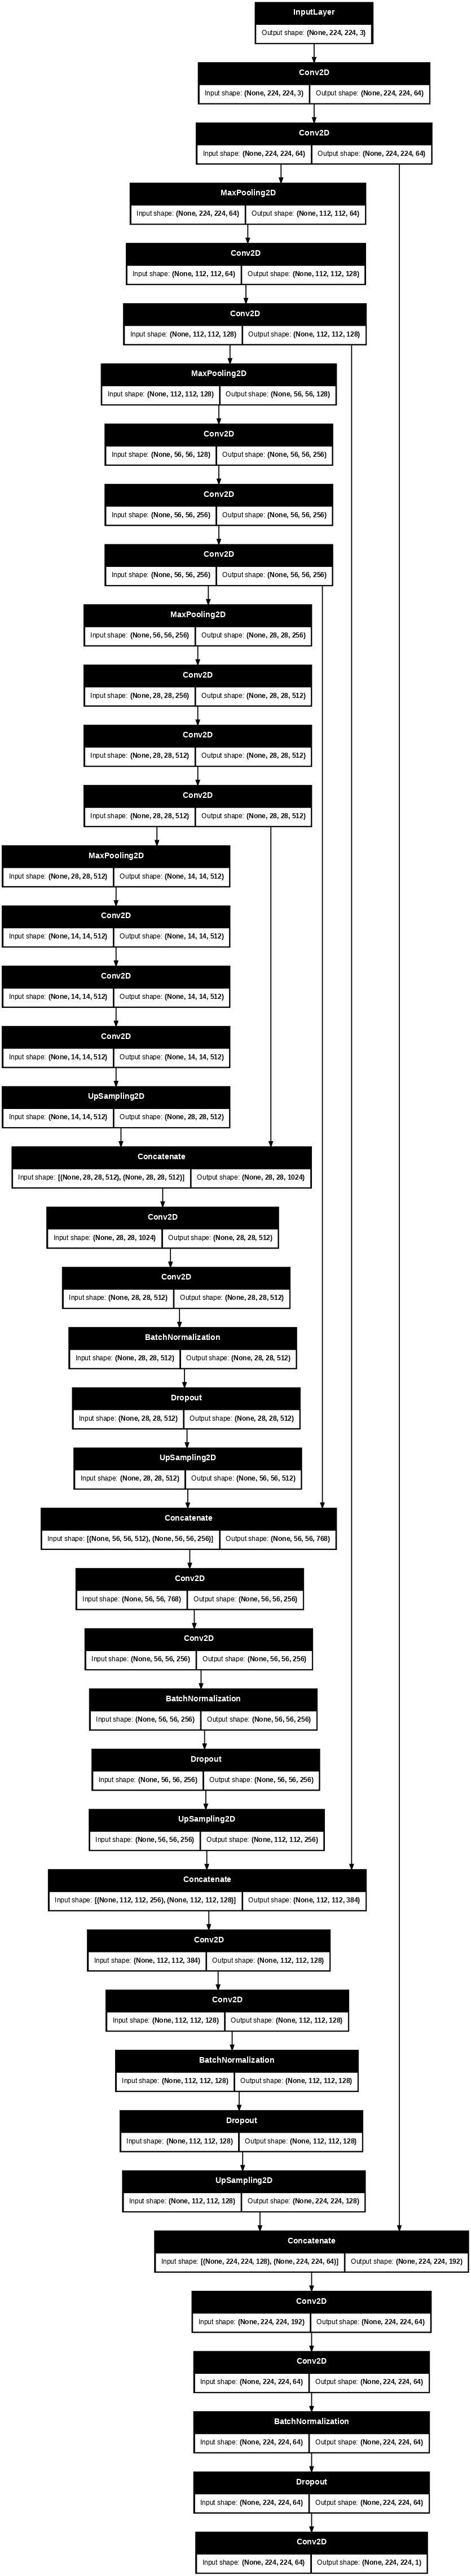

In [57]:
# model architecture

tf.keras.utils.plot_model(model, show_shapes = True, expand_nested = False, dpi = 64)

In [58]:
def create_mask(pred_mask):
    # round to closest
    pred_mask = tf.math.round(pred_mask)
    return pred_mask

def show_predictions(dataset = None, num = 1):
    if dataset:
        for images, masks in dataset.take(num):
            pred_mask = model.predict(images)
            pred_mask = create_mask(pred_mask[0])
            display_sample([image[0], mask[0], pred_mask]) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


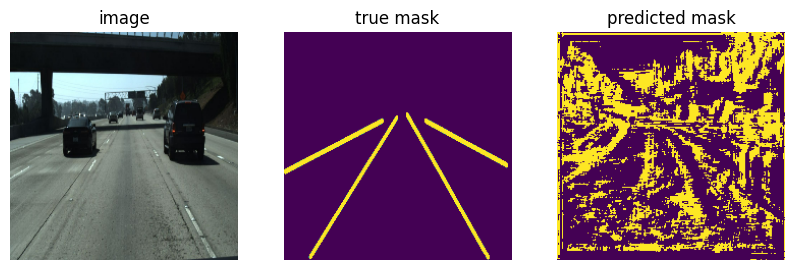

In [59]:
show_predictions(train_dataset, 1) 

In [60]:
# callbacks and logs 

from tensorflow.keras import callbacks
import datetime
import os

class DisplayCallback(callbacks.Callback):   
    def on_epoch_end(self, epoch, logs = None):
        show_predictions(test_dataset, 1)
        print(f"Sample prediction after each epoch {epoch}\n")

log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

callbacks_list = [  
    DisplayCallback(),
    callbacks.TensorBoard(log_dir = log_dir, histogram_freq = 1),
    callbacks.EarlyStopping(patience = 5, verbose = 1),
    callbacks.ModelCheckpoint("best_model.keras", verbose = 1, save_best_only = True)
] 

In [61]:
EPOCHS = 10
steps_per_epoch = len(os.listdir(train_image_folder)) // BATCH_SIZE
validation_steps = len(os.listdir(test_image_folder)) // BATCH_SIZE

## Train the Model

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/stepstep - accuracy: 0.8486 - dice_coefficient: 0.3329 - loss: 0.6671 - precision_smooth: 0.7762 - recall_smooth: 0.77


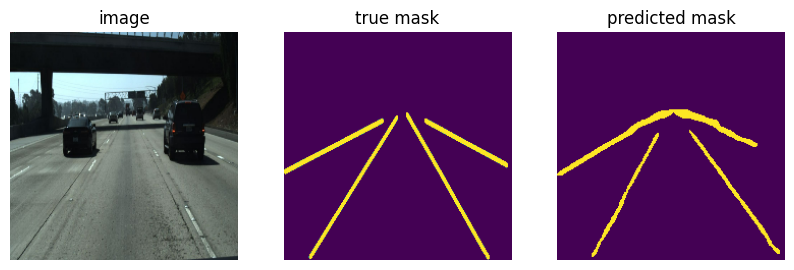

Sample prediction after each epoch 0


Epoch 1: val_loss improved from None to 0.36077, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 91s 535ms/step - accuracy: 0.9164 - dice_coefficient: 0.4617 - loss: 0.5383 - precision_smooth: 0.7870 - recall_smooth: 0.7870 - val_accuracy: 0.9700 - val_dice_coefficient: 0.6392 - val_loss: 0.3608 - val_precision_smooth: 0.6233 - val_recall_smooth: 0.6233
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/stepstep - accuracy: 0.9708 - dice_coefficient: 0.6779 - loss: 0.3221 - precision_smooth: 0.7738 - recall_smooth: 0.77


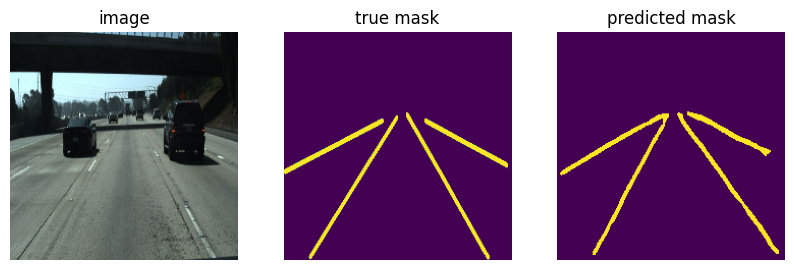

Sample prediction after each epoch 1


Epoch 2: val_loss improved from 0.36077 to 0.30120, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 52s 515ms/step - accuracy: 0.9733 - dice_coefficient: 0.6991 - loss: 0.3009 - precision_smooth: 0.7719 - recall_smooth: 0.7719 - val_accuracy: 0.9768 - val_dice_coefficient: 0.6988 - val_loss: 0.3012 - val_precision_smooth: 0.6344 - val_recall_smooth: 0.6344
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/stepstep - accuracy: 0.9764 - dice_coefficient: 0.7342 - loss: 0.2658 - precision_smooth: 0.7811 - recall_smooth: 0.78


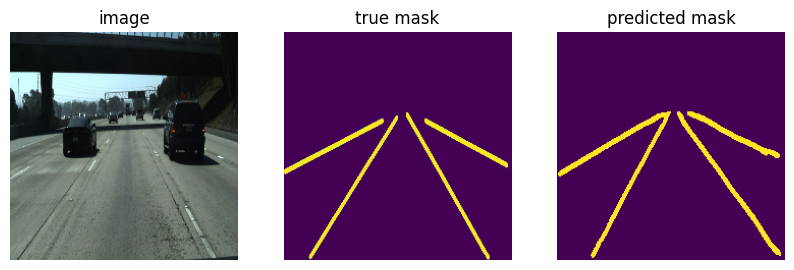

Sample prediction after each epoch 2


Epoch 3: val_loss improved from 0.30120 to 0.25124, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 52s 516ms/step - accuracy: 0.9771 - dice_coefficient: 0.7406 - loss: 0.2594 - precision_smooth: 0.7818 - recall_smooth: 0.7818 - val_accuracy: 0.9780 - val_dice_coefficient: 0.7488 - val_loss: 0.2512 - val_precision_smooth: 0.7732 - val_recall_smooth: 0.7732
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/stepstep - accuracy: 0.9778 - dice_coefficient: 0.7508 - loss: 0.2492 - precision_smooth: 0.7891 - recall_smooth: 0.78


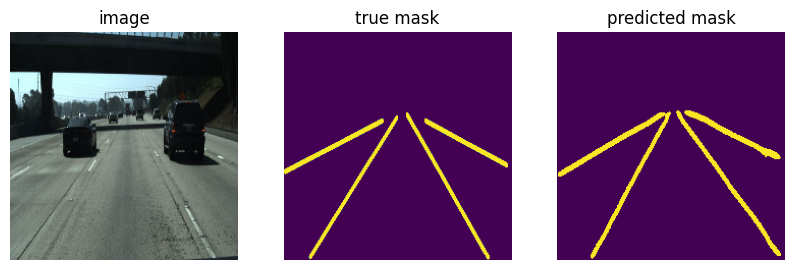

Sample prediction after each epoch 3


Epoch 4: val_loss improved from 0.25124 to 0.23568, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 52s 514ms/step - accuracy: 0.9784 - dice_coefficient: 0.7550 - loss: 0.2450 - precision_smooth: 0.7897 - recall_smooth: 0.7897 - val_accuracy: 0.9790 - val_dice_coefficient: 0.7643 - val_loss: 0.2357 - val_precision_smooth: 0.8064 - val_recall_smooth: 0.8064
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/stepstep - accuracy: 0.9791 - dice_coefficient: 0.7648 - loss: 0.2352 - precision_smooth: 0.7993 - recall_smooth: 0.79


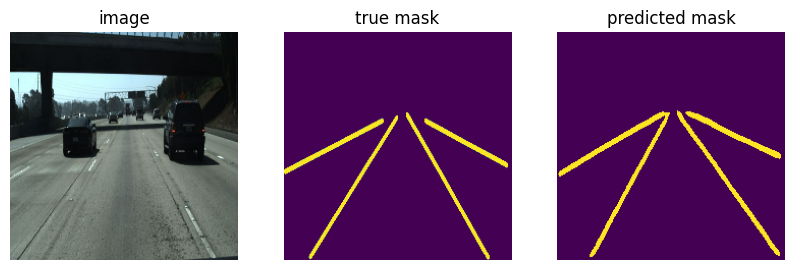

Sample prediction after each epoch 4


Epoch 5: val_loss did not improve from 0.23568
101/101 ━━━━━━━━━━━━━━━━━━━━ 51s 505ms/step - accuracy: 0.9793 - dice_coefficient: 0.7649 - loss: 0.2351 - precision_smooth: 0.7980 - recall_smooth: 0.7980 - val_accuracy: 0.9791 - val_dice_coefficient: 0.7603 - val_loss: 0.2397 - val_precision_smooth: 0.7862 - val_recall_smooth: 0.7862
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/stepstep - accuracy: 0.9796 - dice_coefficient: 0.7711 - loss: 0.2289 - precision_smooth: 0.8032 - recall_smooth: 0.80


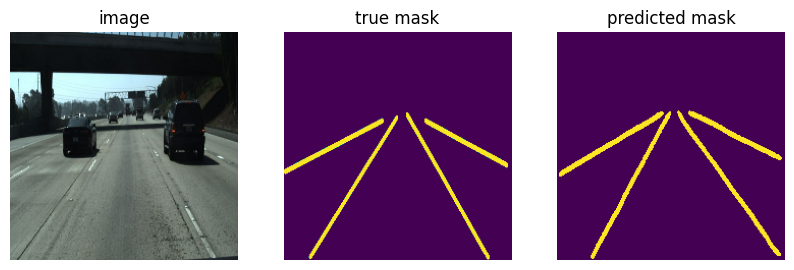

Sample prediction after each epoch 5


Epoch 6: val_loss improved from 0.23568 to 0.23142, saving model to best_model.keras

Epoch 6: finished saving model to best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 52s 515ms/step - accuracy: 0.9798 - dice_coefficient: 0.7709 - loss: 0.2291 - precision_smooth: 0.8017 - recall_smooth: 0.8017 - val_accuracy: 0.9797 - val_dice_coefficient: 0.7686 - val_loss: 0.2314 - val_precision_smooth: 0.7949 - val_recall_smooth: 0.7949
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/stepstep - accuracy: 0.9799 - dice_coefficient: 0.7733 - loss: 0.2267 - precision_smooth: 0.8042 - recall_smooth: 0.80


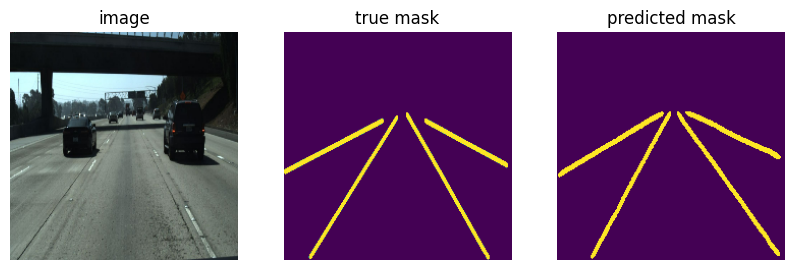

Sample prediction after each epoch 6


Epoch 7: val_loss did not improve from 0.23142
101/101 ━━━━━━━━━━━━━━━━━━━━ 51s 505ms/step - accuracy: 0.9802 - dice_coefficient: 0.7753 - loss: 0.2247 - precision_smooth: 0.8058 - recall_smooth: 0.8058 - val_accuracy: 0.9797 - val_dice_coefficient: 0.7647 - val_loss: 0.2353 - val_precision_smooth: 0.7816 - val_recall_smooth: 0.7816
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/stepstep - accuracy: 0.9806 - dice_coefficient: 0.7806 - loss: 0.2194 - precision_smooth: 0.8110 - recall_smooth: 0.81


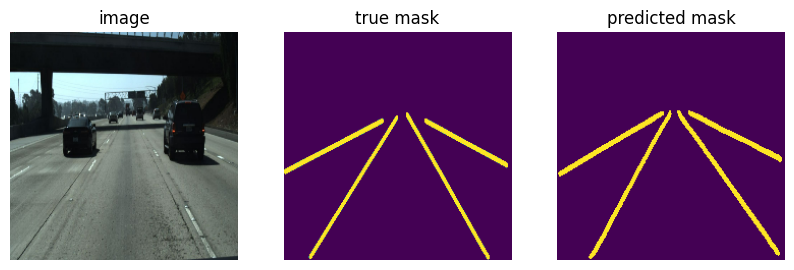

Sample prediction after each epoch 7


Epoch 8: val_loss improved from 0.23142 to 0.22433, saving model to best_model.keras

Epoch 8: finished saving model to best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 52s 515ms/step - accuracy: 0.9808 - dice_coefficient: 0.7820 - loss: 0.2180 - precision_smooth: 0.8109 - recall_smooth: 0.8109 - val_accuracy: 0.9800 - val_dice_coefficient: 0.7757 - val_loss: 0.2243 - val_precision_smooth: 0.8155 - val_recall_smooth: 0.8155
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/stepstep - accuracy: 0.9806 - dice_coefficient: 0.7813 - loss: 0.2187 - precision_smooth: 0.8103 - recall_smooth: 0.81


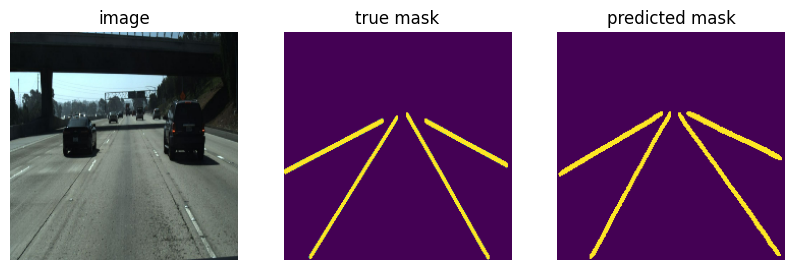

Sample prediction after each epoch 8


Epoch 9: val_loss improved from 0.22433 to 0.22237, saving model to best_model.keras

Epoch 9: finished saving model to best_model.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 52s 514ms/step - accuracy: 0.9809 - dice_coefficient: 0.7828 - loss: 0.2172 - precision_smooth: 0.8113 - recall_smooth: 0.8113 - val_accuracy: 0.9805 - val_dice_coefficient: 0.7776 - val_loss: 0.2224 - val_precision_smooth: 0.8077 - val_recall_smooth: 0.8077
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/stepstep - accuracy: 0.9815 - dice_coefficient: 0.7903 - loss: 0.2097 - precision_smooth: 0.8189 - recall_smooth: 0.81


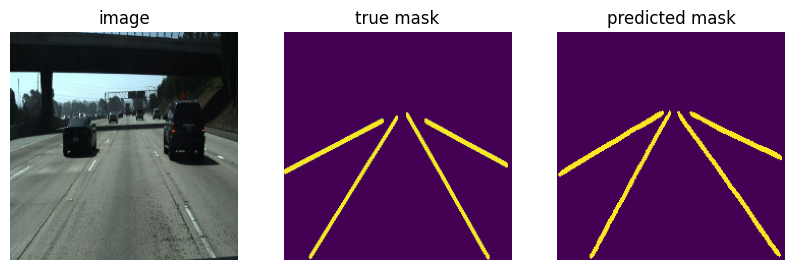

Sample prediction after each epoch 9


Epoch 10: val_loss did not improve from 0.22237
101/101 ━━━━━━━━━━━━━━━━━━━━ 51s 503ms/step - accuracy: 0.9817 - dice_coefficient: 0.7911 - loss: 0.2089 - precision_smooth: 0.8175 - recall_smooth: 0.8175 - val_accuracy: 0.9803 - val_dice_coefficient: 0.7706 - val_loss: 0.2294 - val_precision_smooth: 0.7814 - val_recall_smooth: 0.7814


In [62]:
history = model.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs = EPOCHS,
    steps_per_epoch = steps_per_epoch,
    validation_steps = validation_steps,
    callbacks = callbacks_list   
)

In [74]:
# Save the best model after training
model.save("best_model.keras")

## plot the metrics

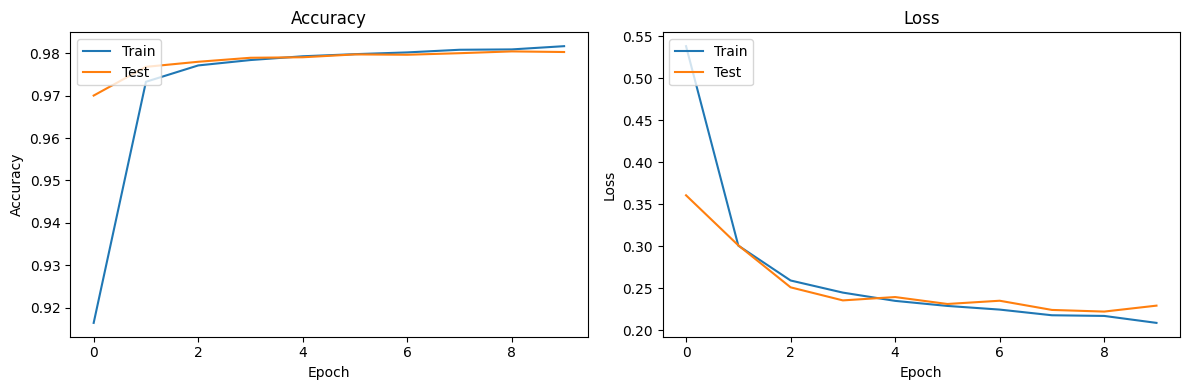

In [66]:
plt.figure(figsize = (12, 4))

# plot train and val accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Test"], loc = "upper left")

# plot train and val loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"], loc = "upper left") 

plt.tight_layout()
plt.show()  

## load the best Model

In [68]:
best_model = tf.keras.models.load_model("best_model.keras",
                                       custom_objects = {
                                           "dice_loss" : dice_loss,
                                           "dice_coefficient" : dice_coefficient,
                                           "precision_smooth" : precision_smooth,
                                           "recall_smooth" : recall_smooth,
                                           "accuracy" : accuracy
                                       })

best_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 55,905,029 (213.26 MB)

 Trainable params: 18,634,369 (71.08 MB)

 Non-trainable params: 1,920 (7.50 KB)

 Optimizer params: 37,268,740 (142.17 MB)

## Test Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


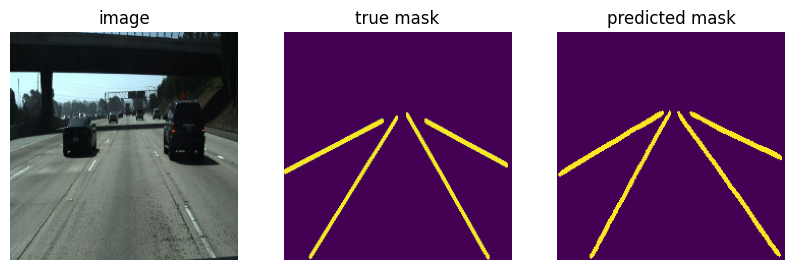

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


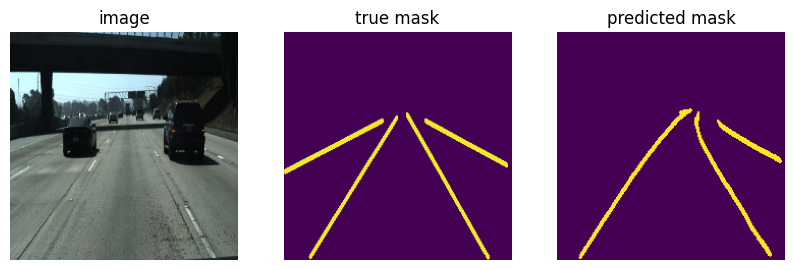

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


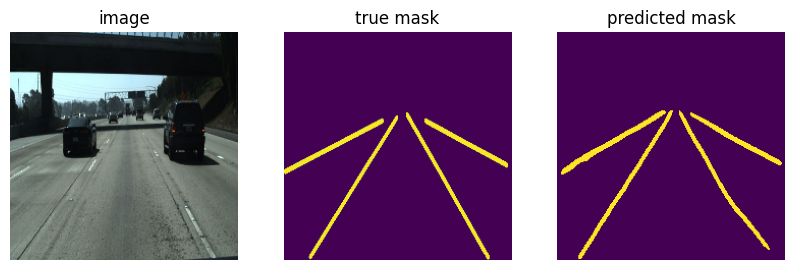

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


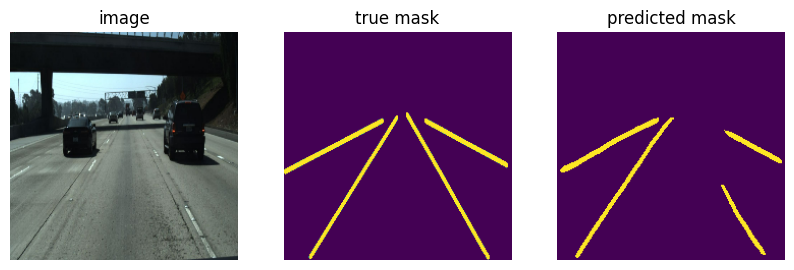

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


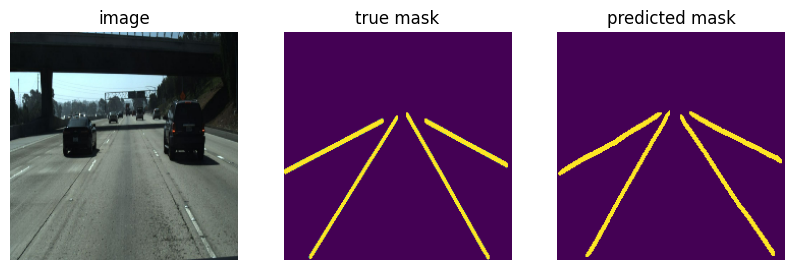

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


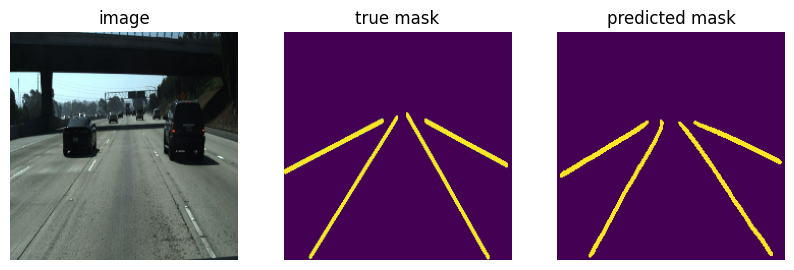

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


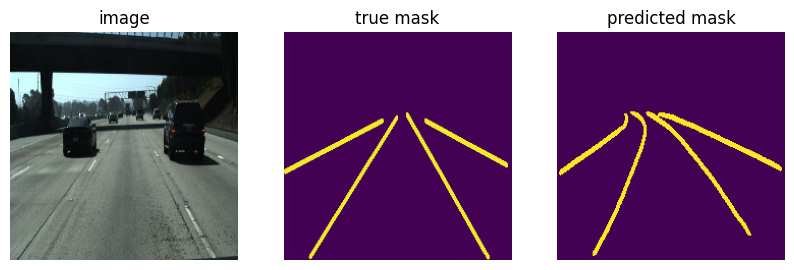

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


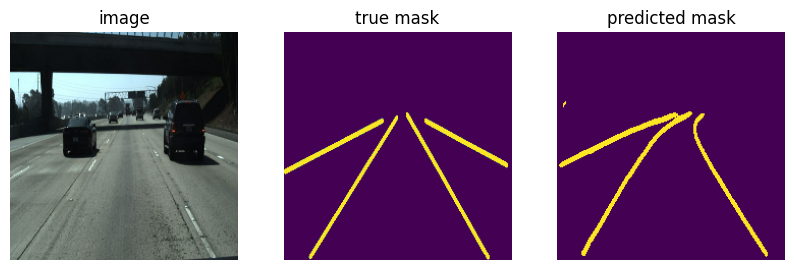

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


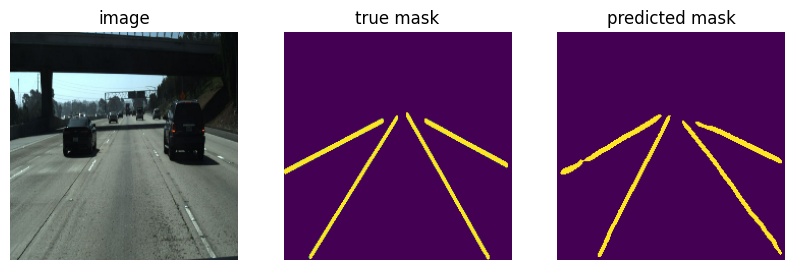

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


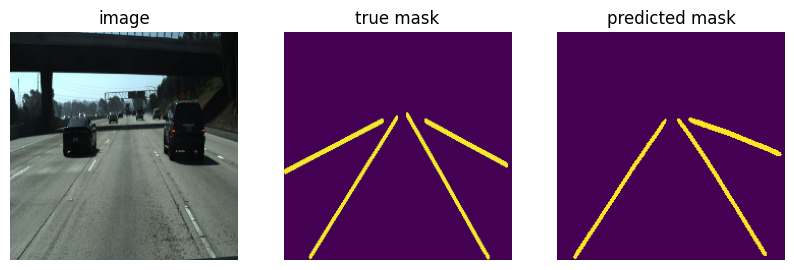

In [70]:
show_predictions(test_dataset, 10)

## test from Real path

In [71]:
def load_test_image(image_path):
    size = [224, 224]
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels = 3)
    image = tf.image.resize(image, size)
    image = image/255.0
    return image

def display_test_sample(image_list):
    plt.figure(figsize = (10, 10))

    titles = ['image', 'predicted mask']

    for i in range(len(image_list)):
        plt.subplot(1, len(image_list), i+1)
        plt.title(titles[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(image_list[i]))
        plt.axis("off")

    plt.show() 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


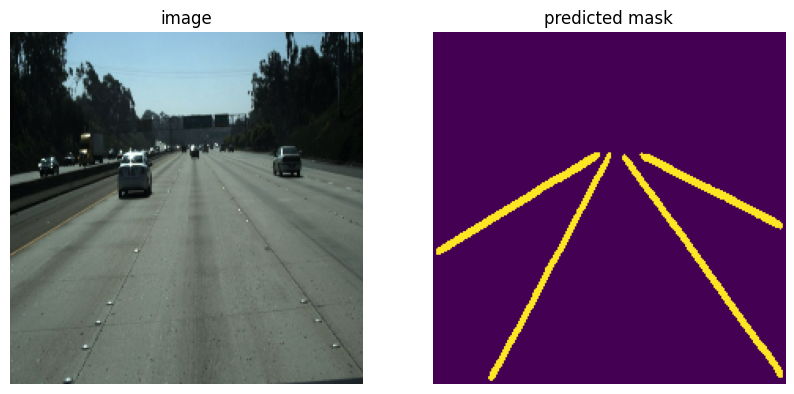

In [73]:
image_path = "/kaggle/input/datasets/manideep1108/tusimple/TUSimple/train_set/clips/0313-1/10000/20.jpg"

image = load_test_image(image_path)
test_image = tf.expand_dims(image, axis = 0)
pred_mask = model.predict([test_image])
pred_mask = create_mask(pred_mask[0])
display_test_sample([image, pred_mask])